<a href="https://colab.research.google.com/github/Hieubui1103/Security_demo/blob/main/Computer_%26_Network_Security.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 12.8 MB/s eta 0:00:00


In [ ]:
import sqlite3
from faker import Faker
import random
from datetime import datetime, timedelta
import pandas as pd
import matplotlib.pyplot as plt
import time

In [ ]:
# Step 1: Create and Populate the Database
from faker import Faker
from faker.providers import BaseProvider
import random

class MedicalProvider(BaseProvider):
    def medical_condition(self):
        conditions = [
            "Hypertension", "Diabetes Mellitus", "Asthma", "Chronic Kidney Disease",
            "Coronary Artery Disease", "Hyperlipidemia", "COPD", "Osteoarthritis",
            "Depression", "Anxiety Disorder", "Hypothyroidism", "Migraine",
            "Gastroesophageal Reflux Disease (GERD)", "Psoriasis", "Anemia"
        ]
        return random.choice(conditions)

    def medical_history(self):
        history_templates = [
            "Patient has a history of {}.",
            "Diagnosed with {} in 2015.",
            "No known history of {}, but family history is positive.",
            "{} diagnosed during routine checkup.",
            "Chronic episodes of {} observed over the last few years."
        ]
        condition = self.medical_condition()
        return random.choice(history_templates).format(condition)

def create_and_populate_database():
    fake = Faker()
    conn = sqlite3.connect("healthcare.db")
    cursor = conn.cursor()
    fake.add_provider(MedicalProvider)
    # Create tables
    cursor.execute("""
    CREATE TABLE IF NOT EXISTS patients (
        patient_id INTEGER PRIMARY KEY,
        name TEXT,
        age INTEGER,
        address TEXT,
        medical_history TEXT
    )
    """)
    cursor.execute("""
    CREATE TABLE IF NOT EXISTS access_logs (
        log_id INTEGER PRIMARY KEY,
        user_id TEXT,
        user_role TEXT,
        timestamp TEXT,
        action TEXT,
        patient_id INTEGER,
        access_range TEXT
    )
    """)

    # Populate patients table
    for _ in range(100):  # Create 100 patient records
        cursor.execute("""
        INSERT INTO patients (name, age, address, medical_history)
        VALUES (?, ?, ?, ?)
        """, (fake.name(), random.randint(18, 90), fake.address(), fake.medical_history()))

    # Create redacted view
    cursor.execute("DROP VIEW IF EXISTS redacted_patients")
    cursor.execute("""
    CREATE VIEW redacted_patients AS
    SELECT
        patient_id,
        'XXXX' AS name,
        'XXXX' AS address,
        substr(medical_history, 1, instr(medical_history, '.') + 1) AS medical_history
    FROM patients
    """)

    conn.commit()
    conn.close()
    print("Database created and populated with synthetic data.")

In [ ]:
print("Step 1: Creating and populating the database...")
create_and_populate_database()

Step 1: Creating and populating the database...
Database created and populated with synthetic data.


In [ ]:
# Step 1.5: Conditional Access Based on Identity Verification
def verify_user_access(user_id, user_role):
    valid_roles = ["doctor", "admin"]
    doctor_id = 3000 <= int(user_id) <= 4999
    admin_id = 5000 <= int(user_id) <= 6999
    chances = random.randint(0, 1)
    if user_role in valid_roles and (doctor_id or admin_id):
        if chances == 0:
          return False
        else:
          return True
    return False

# def get_patient_data(user_id, user_role, work_id=None):
#     conn = sqlite3.connect("healthcare.db")
#     if verify_user_access(user_id, user_role, work_id):
#         print("✅ Identity verified. Accessing full patient data.")
#         df = pd.read_sql_query("SELECT * FROM patients", conn)
#     else:
#         print("⚠️ Unverified. Showing redacted data only.")
#         df = pd.read_sql_query("SELECT * FROM redacted_patients", conn)
#     conn.close()
#     return df

In [ ]:
# Step 2: Simulate Access Logs (with anomalies)
def generate_user_id(role):
    if role == "nurse":
        return f"{random.randint(0, 2999):04d}"
    elif role == "doctor":
        return f"{random.randint(3000, 4999):04d}"
    elif role == "admin":
        return f"{random.randint(5000, 6999):04d}"
    elif role == "researcher":
        return f"{random.randint(7000, 9999):04d}"

def simulate_access_logs():
    conn = sqlite3.connect("healthcare.db")
    cursor = conn.cursor()

    roles = ["doctor", "nurse", "admin", "researcher"]
    actions = ["read", "write", "delete"]
    current_time = datetime.now()


    # Normal access logs
    for _ in range(450):  # Simulate 450 normal access events
        user_role = random.choice(roles)
        user_id = generate_user_id(user_role)
        # Generate random hour and minute
        random_hour = random.randint(9, 17)  # Hour can be between 0 and 23
        random_minute = random.randint(0, 59)  # Minute can be between 0 and 59
        timestamp = current_time.replace(hour=random_hour, minute=random_minute).strftime("%Y-%m-%d %H:%M:%S")
        action = ""

        if user_role == "researcher":
            action = "read"  # Researcher can only read
        else:
          action = random.choice(actions)

        patient_id = random.randint(1, 100)  # Access one of the 100 patients
        verified_status = verify_user_access(user_id,user_role)
        access_range = "full" if verified_status else "limited"

        cursor.execute("""
        INSERT INTO access_logs (user_id, user_role, timestamp, action, patient_id, access_range)
        VALUES (?, ?, ?, ?, ?,?)
        """, (user_id, user_role, timestamp, action, patient_id, access_range))

        time.sleep(0.01)  # Simulate a small delay between actions

    # Simulate high access anomaly
    for _ in range(60):  # User 9999 accesses 60 records in a short time
        user_id =  "6998"# Deliberately use the same user ID
        user_role = "admin"
        time_increment = timedelta(seconds=random.uniform(0.5, 1.5))
        current_time += time_increment
        timestamp = current_time.replace(hour=10, minute=19).strftime("%Y-%m-%d %H:%M:%S")
        action = "read"
        patient_id = random.randint(1, 100)
        access_range = "full"

        cursor.execute("""
        INSERT INTO access_logs (user_id, user_role, timestamp, action, patient_id, access_range)
        VALUES (?, ?, ?, ?, ?, ?)
        """, (user_id, user_role, timestamp, action, patient_id, access_range))

    # Simulate off-hour anomaly
    # One-user access
    for _ in range(27): # User 0089 accesses records outside normal hours
        user_id = "0089"
        user_role = "nurse"

        # Increment the timestamp by a random interval between 1 and 2 seconds
        time_increment = timedelta(seconds=random.uniform(0.5, 1.5))
        current_time += time_increment
        timestamp = current_time.replace(hour=19, minute=37).strftime("%Y-%m-%d %H:%M:%S")

        action = "read"
        patient_id = random.randint(1, 100)
        access_range = "limited"

        cursor.execute("""
        INSERT INTO access_logs (user_id, user_role, timestamp, action, patient_id, access_range)
        VALUES (?, ?, ?, ?, ?, ?)
        """, (user_id, user_role, timestamp, action, patient_id, access_range))

    # multiple-user access
    for _ in range(50):  # Simulate 50 off-hour access events
        user_role = random.choice(roles)
        user_id = generate_user_id(user_role)
        # Generate random hour and minute
        random_hour = random.choice(list(range(0, 9)) + list(range(18, 24)))
        random_minute = random.randint(0, 59)  # Minute can be between 0 and 59
        timestamp = current_time.replace(hour=random_hour, minute=random_minute).strftime("%Y-%m-%d %H:%M:%S")
        action = ""

        if user_role == "researcher":
            action = "read"  # Researcher can only read
        else:
          action = random.choice(actions)

        patient_id = random.randint(1, 100)  # Access one of the 100 patients
        verified_status = verify_user_access(user_id,user_role)
        access_range = "full" if verified_status else "limited"

        cursor.execute("""
        INSERT INTO access_logs (user_id, user_role, timestamp, action, patient_id, access_range)
        VALUES (?, ?, ?, ?, ?,?)
        """, (user_id, user_role, timestamp, action, patient_id, access_range))

        time.sleep(0.01)  # Simulate a small delay between actions

    conn.commit()
    conn.close()
    print("Access logs simulated (including anomalies) and stored in the database.")


In [ ]:
print("\nStep 2: Simulating access logs (with anomalies)...")
simulate_access_logs()


Step 2: Simulating access logs (with anomalies)...
Access logs simulated (including anomalies) and stored in the database.


In [ ]:
# Step 3: Anomalies detection
def detect_anomalies():
    conn = sqlite3.connect("healthcare.db")
    logs_df = pd.read_sql_query("SELECT * FROM access_logs", conn)

    logs_df['timestamp'] = pd.to_datetime(logs_df['timestamp'])
    logs_df['minute'] = logs_df['timestamp'].dt.floor('T')
    logs_df['hour'] = logs_df['timestamp'].dt.hour

    patients_df = pd.read_sql_query("SELECT * FROM patients", conn)
    redacted_df = pd.read_sql_query("SELECT * FROM redacted_patients", conn)

    # High accesss detection: 20 accesses in 30s
    def detect_high_access(df, threshold=20, window_seconds=30):
      df['timestamp'] = pd.to_datetime(df['timestamp'])
      df = df.sort_values(by=['user_id', 'timestamp'])

      flagged_users = []

      # Group by user and check sliding windows
      for user_id, group in df.groupby('user_id'):
          timestamps = group['timestamp'].tolist()

          for i in range(len(timestamps)):
              window_start = timestamps[i]
              window_end = window_start + pd.Timedelta(seconds=window_seconds)

              # Count accesses in this 20-second window
              count = sum((ts >= window_start and ts <= window_end) for ts in timestamps)

              if count > threshold:
                  flagged_users.append((user_id, window_start, count))
                  break  # Only report first occurrence

      return flagged_users

    def detect_off_hours(df):
        return df[(df['hour'] < 9) | (df['hour'] > 17)]

    high_access = detect_high_access(logs_df)
    off_hours = detect_off_hours(logs_df)

    print("\n🧨 High Total Access Anomalies:")
    if high_access:  # Just check if the list is not empty
      for user_id, window_start, count in high_access:
          print(f"User ID {user_id} accessed {count} records within 30s starting at {window_start}.")
    else:
        print("No high total access anomalies detected.")

    print("\n🌙 Off-Hours Access Anomalies:")
    if not off_hours.empty:
        for _, row in off_hours.iterrows():
            redacted = redacted_df[redacted_df['patient_id'] == row['patient_id']].iloc[0]
            print(f"User ID {row['user_id']} accessed patient ID {redacted['patient_id']} at {row['timestamp']}.")
    else:
        print("No off-hours access anomalies detected.")


    conn.close()

In [ ]:
# Step 4: Visualization
def visualize_access_patterns():
    conn = sqlite3.connect("healthcare.db")
    query = "SELECT * FROM access_logs"
    logs_df = pd.read_sql_query(query, conn)

    # Plot access counts per user (Top 10)
    access_counts = logs_df.groupby("user_id").size().sort_values(ascending=False).head(10)  # Get top 10
    access_counts.plot(kind="bar", title="Access Counts per User (Top 10)", xlabel="User ID", ylabel="Number of Accesses", figsize=(10, 6))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Plot access times
    logs_df['timestamp'] = pd.to_datetime(logs_df['timestamp'])
    logs_df['hour'] = logs_df['timestamp'].dt.hour
    logs_df['hour'].value_counts().sort_index().plot(kind="bar", title="Access Times", xlabel="Hour of Day", ylabel="Number of Accesses")
    plt.show()

    conn.close()

In [ ]:

print("\nStep 3: Detecting anomalies...")
detect_anomalies()



Step 3: Detecting anomalies...


<ipython-input-8-f49bd058a324>:7: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  logs_df['minute'] = logs_df['timestamp'].dt.floor('T')



🧨 High Total Access Anomalies:
User ID 0089 accessed 27 records within 30s starting at 2025-04-25 19:37:10.
User ID 6998 accessed 29 records within 30s starting at 2025-04-25 10:19:00.

🌙 Off-Hours Access Anomalies:
User ID 0089 accessed patient ID 96 at 2025-04-25 19:37:10.
User ID 0089 accessed patient ID 90 at 2025-04-25 19:37:11.
User ID 0089 accessed patient ID 32 at 2025-04-25 19:37:12.
User ID 0089 accessed patient ID 17 at 2025-04-25 19:37:13.
User ID 0089 accessed patient ID 26 at 2025-04-25 19:37:14.
User ID 0089 accessed patient ID 18 at 2025-04-25 19:37:15.
User ID 0089 accessed patient ID 97 at 2025-04-25 19:37:16.
User ID 0089 accessed patient ID 34 at 2025-04-25 19:37:17.
User ID 0089 accessed patient ID 45 at 2025-04-25 19:37:18.
User ID 0089 accessed patient ID 63 at 2025-04-25 19:37:19.
User ID 0089 accessed patient ID 56 at 2025-04-25 19:37:20.
User ID 0089 accessed patient ID 64 at 2025-04-25 19:37:22.
User ID 0089 accessed patient ID 24 at 2025-04-25 19:37:23.
Use


Step 4: Visualizing access patterns...


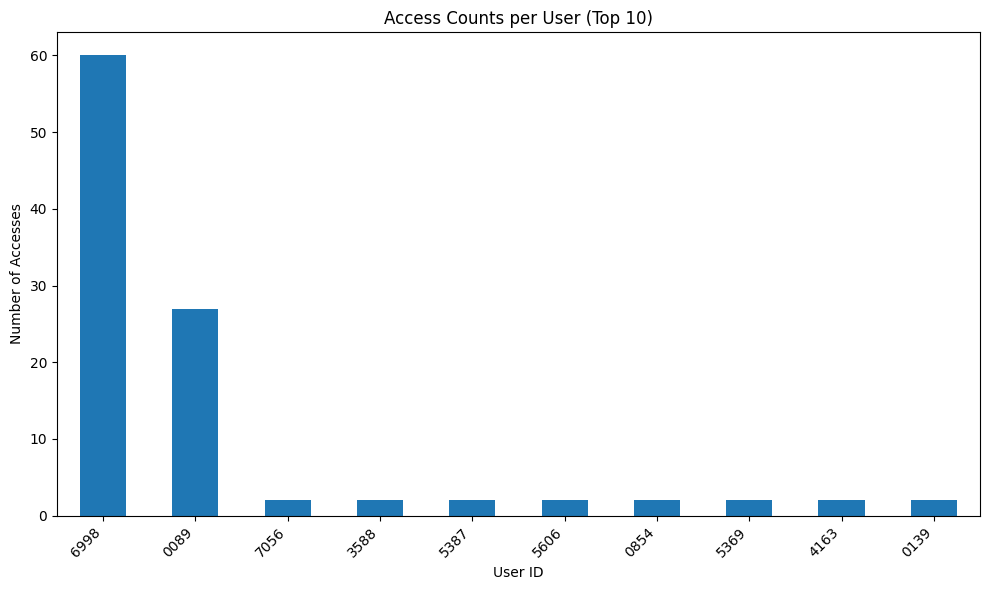

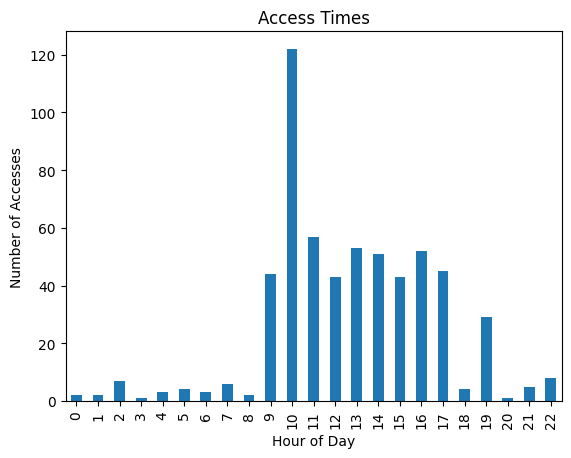

In [ ]:
print("\nStep 4: Visualizing access patterns...")
visualize_access_patterns()

In [ ]:
import sqlite3
import pandas as pd

def view_table_data(table_name):
  """Displays the data of a specified table in the database."""
  conn = sqlite3.connect("healthcare.db")
  df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
  conn.close()
  return df

# View data in the 'patients' table
patients_data = view_table_data("patients")
print(patients_data)

# View data in the 'access_logs' table
access_logs_data = view_table_data("access_logs")
print(access_logs_data)

    patient_id                  name  age  \
0            1         Krista Turner   18   
1            2      Samantha Griffin   48   
2            3            Erin Clark   58   
3            4           Kathy Baird   47   
4            5        Jill Hernandez   38   
..         ...                   ...  ...   
95          96          Morgan Terry   25   
96          97       Joseph Erickson   74   
97          98  Christopher Robinson   75   
98          99        Stephen Becker   75   
99         100          Heidi Morris   63   

                                              address  \
0           55749 Herring Estate\nKellyfort, SC 75561   
1          87811 Daniel Radial\nBradleyfort, NY 89427   
2    8497 Guerra Common\nWest Arthurborough, NC 71681   
3              684 Morrison Field\nLukeberg, DC 51186   
4             26438 James Unions\nReedshire, KY 98775   
..                                                ...   
95   6784 Daniel Pines Suite 328\nEmmamouth, VT 73513   
96 

In [ ]:
import sqlite3
import pandas as pd

def export_table_to_csv(table_name, csv_file_name):
    """Exports a specified table to a CSV file."""
    conn = sqlite3.connect("healthcare.db")
    df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    conn.close()
    df.to_csv(csv_file_name, index=False)  # Set index=False to avoid saving row indices
    print(f"Table '{table_name}' exported to '{csv_file_name}' successfully.")

# Export the 'patients' table to 'patients.csv'
export_table_to_csv("patients", "patients.csv")

Table 'patients' exported to 'patients.csv' successfully.


In [ ]:
def export_redacted_patients(csv_file_name="patients_redacted.csv"):
    """Exports redacted patient data to a CSV file."""
    conn = sqlite3.connect("healthcare.db")
    patients_df = pd.read_sql_query("SELECT * FROM patients", conn)
    conn.close()

    # Redact sensitive fields
    def redact(row):
        return {
            "patient_id": row["patient_id"],
            "name": "[REDACTED]",
            "address": "[REDACTED]",
            "medical_history": row["medical_history"].split('.')[0] + ".",
            "redacted": True
        }

    redacted_df = patients_df.apply(redact, axis=1).apply(pd.Series)
    redacted_df.to_csv(csv_file_name, index=False)
    print(f"Redacted patient data exported to '{csv_file_name}' successfully.")
export_redacted_patients()

Redacted patient data exported to 'patients_redacted.csv' successfully.


In [ ]:
# Export the "acces_logs" table
export_table_to_csv("access_logs", "access_logs.csv")

Table 'access_logs' exported to 'access_logs.csv' successfully.
